In [1]:
"""
https://catboost.ai/docs/en/concepts/python-reference_catboostregressor_fit

To drop: numwrk, totwag, unempdur
Fillna: immigr (3.0), disabl (0.0), 
Filter nan rows: mart_d, yeduc
"""

'\nhttps://catboost.ai/docs/en/concepts/python-reference_catboostregressor_fit\n\nTo drop: numwrk, totwag, unempdur\nFillna: immigr (3.0), disabl (0.0), \nFilter nan rows: mart_d, yeduc\n'

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio
import catboost

from tqdm.auto import tqdm
from pathlib import Path

In [3]:
src_dir = (
    Path("~").expanduser()
    / "OneDrive - Stichting Deltares/Tiaravanni Hermawan's files - Egypt/04_Data/2026_data/"
)
excel_path = (
    Path("~").expanduser()
    / "OneDrive - Stichting Deltares/Tiaravanni Hermawan's files - Egypt_ERF_data/data_correlation.xlsx"
)

In [4]:
survey_df = pd.read_csv(src_dir.parent / "Result/ind_survey_data_gov_assigned.csv")
distribution_df = pd.read_csv(
    src_dir.parent / "Result/population_density_matrix.csv", index_col="NAME1_"
)
masking_df = pd.read_excel(
    src_dir.parent / "Result/correlation.xlsx", sheet_name="Sheet1"
)
excel_df = pd.read_excel(excel_path, sheet_name="command_unit")

In [5]:
survey_df['sempinc'] = survey_df['sempinc'].fillna(0)
survey_df['irrgwag'] = survey_df['irrgwag'].fillna(0)
survey_df['totwag'] = survey_df['totwag'].fillna(0)

survey_df['totwag'] = survey_df['totwag'] + survey_df['sempinc'] + survey_df['irrgwag'] * 30

In [6]:
(~survey_df['irrgwag'].isna()).sum()

np.int64(13919)

In [7]:
female_df = survey_df[survey_df['sex_label'] == 'Female']
male_df = survey_df[survey_df['sex_label'] == 'Male']

In [8]:
(~male_df['sempinc'].isna()).sum()

np.int64(11908)

In [9]:
governorates = survey_df[survey_df["NAME1_"].notna()]["NAME1_"].unique()

rng = np.random.default_rng(seed=42)
sample_df = survey_df.copy(deep=True)
sample_df["command_unit"] = None
command_units = distribution_df.columns

gov_indices = {
    gov: idx.to_numpy() for gov, idx in survey_df.groupby("NAME1_").groups.items()
}
female_gov_indices = {
    gov: idx.to_numpy() for gov, idx in female_df.groupby("NAME1_").groups.items()
}
male_gov_indices = {
    gov: idx.to_numpy() for gov, idx in male_df.groupby("NAME1_").groups.items()
}

for gov, idx in gov_indices.items():
    probs = distribution_df.loc[gov].to_numpy()

    assignments = rng.choice(
        command_units,
        size=len(idx),
        p=probs,
    )

    sample_df.loc[idx, "command_unit"] = assignments

sample_df.loc[sample_df["command_unit"] == "other", "command_unit"] = None

sample_df = sample_df[sample_df["command_unit"].notna()]
final_sample = sample_df.merge(
    excel_df, left_on="command_unit", right_on="area", suffixes=("", "_spatial")
)

to_correlate = masking_df.loc[masking_df["correl"] == 1, "variable"]
final_sample = final_sample.dropna(subset=['mart_d', 'yeduc'])
final_sample['hrswksc'] = final_sample['hrswksc'].fillna(0)
final_sample['hrswk'] = final_sample['hrswk'] + final_sample['hrswksc']

final_sample['immigr'] = final_sample['immigr'].fillna(3)
final_sample['disabl'] = final_sample['disabl'].fillna(0)

final_sample = final_sample.drop(columns=['unempdur', 'numwrk'])
cols = [c for c in to_correlate if c in final_sample.columns]

In [10]:
categorical_columns = masking_df[(masking_df["type"] == 'binary') | (masking_df["type"] == 'categorical') & (masking_df["variable"].isin(cols))]['variable'].values.tolist()
final_sample[categorical_columns] = final_sample[categorical_columns].astype(str)

In [11]:
model = catboost.CatBoostRegressor()
model.fit(X=final_sample[cols].drop(columns=['hrswk', 'hrswksc', 'totwag']), y=final_sample['totwag'], cat_features=categorical_columns)

Learning rate set to 0.060431
0:	learn: 2896.5608495	total: 63ms	remaining: 1m 2s
1:	learn: 2869.0069590	total: 69.5ms	remaining: 34.7s
2:	learn: 2845.5377879	total: 74.9ms	remaining: 24.9s
3:	learn: 2824.2842062	total: 80.2ms	remaining: 20s
4:	learn: 2804.6456202	total: 86.5ms	remaining: 17.2s
5:	learn: 2786.7935849	total: 90.4ms	remaining: 15s
6:	learn: 2771.8055823	total: 95.3ms	remaining: 13.5s
7:	learn: 2758.1780266	total: 99.4ms	remaining: 12.3s
8:	learn: 2745.8532113	total: 103ms	remaining: 11.4s
9:	learn: 2735.3455221	total: 107ms	remaining: 10.5s
10:	learn: 2726.1284737	total: 111ms	remaining: 9.94s
11:	learn: 2717.9530026	total: 114ms	remaining: 9.35s
12:	learn: 2709.7879364	total: 117ms	remaining: 8.88s
13:	learn: 2702.0652128	total: 121ms	remaining: 8.51s
14:	learn: 2695.4926250	total: 125ms	remaining: 8.22s
15:	learn: 2689.1699937	total: 128ms	remaining: 7.89s
16:	learn: 2684.1379247	total: 133ms	remaining: 7.66s
17:	learn: 2679.3126539	total: 136ms	remaining: 7.42s
18:	le

CatBoostRegressor(loss_function='RMSE')

In [12]:
y.describe()

NameError: name 'y' is not defined

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from catboost import CatBoostRegressor

final_sample_female = final_sample[final_sample['sex'] == '1']
final_sample_female = final_sample_female[final_sample_female['totwag'] > 0]

X = final_sample_female[cols].drop(columns=["hrswk", "hrswksc", "totwag"])
y = final_sample_female["totwag"]
y = np.log1p(final_sample_female["totwag"])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100,
)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_columns,
)

# predictions on unseen data
y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

0:	learn: 0.4143921	total: 4.99ms	remaining: 1.49s
100:	learn: 0.3382074	total: 446ms	remaining: 878ms
200:	learn: 0.3286856	total: 857ms	remaining: 422ms
299:	learn: 0.3229779	total: 1.24s	remaining: 0us
R²: 0.26034211219805026
MAE: 0.21279482870711808
RMSE: 0.36211177199375405


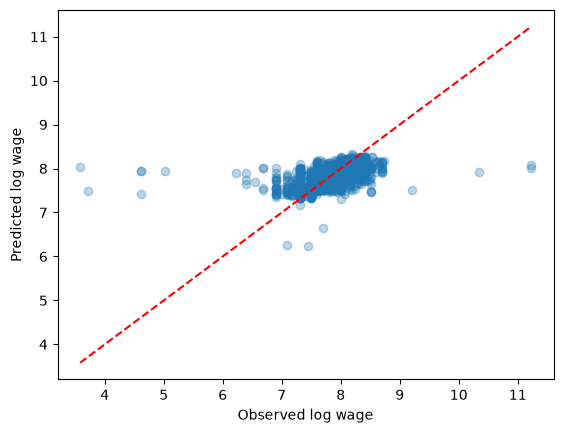

In [29]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)
# plt.xlim(0
# plt.ylim(0, 8000)
plt.xlabel("Observed log wage")
plt.ylabel("Predicted log wage")
plt.show()

In [73]:
baseline = np.repeat(y_train.mean(), len(y_test))

print("R²:", r2_score(y_test, baseline))
print("Baseline RMSE:", root_mean_squared_error(y_test, baseline))
print("Model RMSE:", root_mean_squared_error(y_test, y_pred))

R²: -0.0005562787035531258
Baseline RMSE: 2327.6841128403
Model RMSE: 2312.4965347386815


In [88]:
X.columns

Index(['age', 'sex', 'mart_d', 'immigr', 'disabl', 'lit', 'yeduc', 'emps',
       'tenure', 'hlthins', 'socsec', 'secjob', 'household_size',
       'n_other_employed', 'command_unit', 'water_productivity',
       'surface_water_mean', 'ground_water_mean', 'supply_demand_ratio',
       'water_supply', 'water_demand', 'gdp_pc', 'rwi_median', 'precipitation',
       'potentialevapotransporation', 'drain_length', 'canal_length', 'cattle',
       'chicken', 'goats', 'sheeps',
       'salinity_production_Maize (incl. 0067 and 0068)',
       'salinity_cultivation_area_Maize (incl. 0067 and 0068)',
       'salinity_production_Wheat', 'salinity_cultivation_area_Wheat',
       'salinity_production_Rice, paddy',
       'salinity_cultivation_area_Rice, paddy',
       'salinity_production_Sugar cane',
       'salinity_cultivation_area_Sugar cane',
       'salinity_production_Alfalfa for forage',
       'salinity_cultivation_area_Alfalfa for forage', 'fraction_small',
       'fraction_medium', 'frac

In [94]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from catboost import CatBoostRegressor, CatBoostClassifier

final_sample_female = final_sample[final_sample['sex'] == '2']
# final_sample_female = final_sample_female[final_sample_female['totwag'] > 0]

X = final_sample_female[cols].drop(columns=["hrswk", "hrswksc", "totwag"])
X = X.drop(columns="emps")
y = final_sample_female["totwag"]
y[y > 0] = 1
y = y.astype(int)
# y = np.log1p(final_sample_female["totwag"])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.03,
    depth=8,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100,
)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_columns,
)

# predictions on unseen data
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

0:	total: 2.77ms	remaining: 275ms
99:	total: 225ms	remaining: 0us
Accuracy: 0.8770949720670391
F1: 0.7105263157894737
AUC: 0.8893413072061755


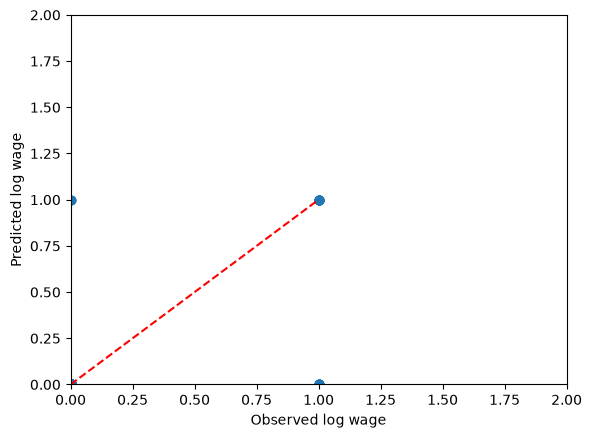

In [95]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)
plt.xlim(0, 2)
plt.ylim(0, 2)
plt.xlabel("Observed log wage")
plt.ylabel("Predicted log wage")
plt.show()

In [30]:
imp = (
    pd.Series(
        model.feature_importances_,
        index=X_train.columns
    )
    .sort_values(ascending=False)
)

print(imp.head(20))

emps                                22.548213
female_child_married                10.403974
female_violence_sexual               7.276989
tenure                               5.252470
female_contraceptives_decision       4.734981
female_unemployment_rate             3.968029
empstab                              3.915762
female_violence_physical             3.170413
age                                  2.799767
female_violence_emotional            2.583447
command_unit                         2.421778
female_healthcare_decision           2.319910
household_size                       2.119636
yeduc                                1.994682
female_circumcised                   1.947289
p_middle_class                       1.807139
n_other_employed                     1.500458
female_labour_participation_rate     1.426709
precipitation                        1.323957
mart_d                               1.299643
dtype: float64


In [13]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score

baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)

print(r2_score(y_test, y_pred_base))

-0.0003372369011436227


In [14]:
from sklearn.metrics import r2_score

print("Train R²:", r2_score(y_train, model.predict(X_train)))
print("Test R² :", r2_score(y_test, y_pred))

Train R²: 0.5128466617481675
Test R² : 0.410414401946423


<Axes: >

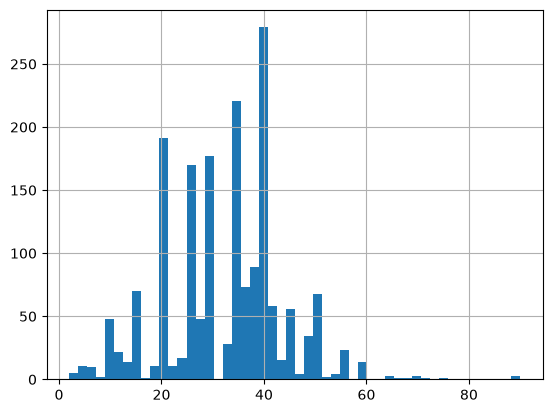

In [26]:
final_sample_female["hrswk"].hist(bins=50)